# Comparison of SVM and Deep Learning Models

Best possible SVM (whichever of `3.2a`'s direct model or `3.2b`'s residual-on-baseline model won on
validation) vs. the neural network (`3.3`), compared at `h3_7/hourly`. Rather than re-loading and
re-running the models, this notebook loads only their **already-computed predictions on the held-out
test split** — one parquet per model — plus the historical-mean baseline (`base_demand`, computed
train-only in `3.1`). Everything below — the metrics table, the spatial error maps, calibration, and
the day-of-week / demand-segment breakdowns — is therefore an honest out-of-sample view on the
**test** set. The choropleth helpers are reused from `2.3 TempHexagonVis.ipynb`.

All three signals (baseline, SVM, NN) live as columns of a single `testing_df`, so each cell is just
a different slice/aggregation of that one frame.

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h3
import geopandas as gpd
import contextily as ctx
import shapely
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INDEX = "h3_index_7"
TRUTH = "y_true"
BASELINE_COL = "base_demand"

SVR_DIR = Path("../models_predictions/SVR/residual/predictions")
FNN_DIR = Path("../models_predictions/FNN/standard/h3_7")

predictions = {
    "svm": {"col": "y_pred_svr", "name": "Best SVM (Residual SVR)"},
    "nn": {"col": "y_pred_fnn", "name": "Neural Network (FNN)"},
}

def score(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def load_comparison(temporal):
    svr = pd.read_parquet(SVR_DIR / f"test_pred_h3_7_{temporal}.parquet")
    fnn = pd.read_parquet(FNN_DIR / f"FNN_h3_7_{temporal}.parquet")
    svr.rename(columns={"Total_Trip_Start": "y_true", "SVR_pred": "y_pred"}, inplace=True)
    return svr.merge(fnn, on=[INDEX, "timestamp", "y_true"], suffixes=("_svr", "_fnn"))

comparisons = {
    "daily": load_comparison("daily"),
    "hourly": load_comparison("hourly"),
}

print("Loaded:")
for temporal, df in comparisons.items():
    print(f"h3_7/{temporal}: {len(df)} rows")

testing_df

Loaded:
  h3_7/daily: 30821 rows
  h3_7/hourly: 739704 rows


,timestamp,h3_index_7,y_true,lat,lon,distance_to_loop,is_holiday,is_near_holiday,month,day_of_week,...,poi_cat_leisure_sports,poi_cat_lodging,poi_cat_nightlife,poi_cat_services,poi_cat_shopping,poi_cat_transport,base_demand,y_pred_svr,y_pred_fnn,is_rainy
0,2025-08-27,872664191ffffff,0.0,41.660879,-87.532242,25.472952,0,0,8,2,...,0,0,2,0,0,1,0.00,0.125841,0.0,0
1,2025-08-27,872664193ffffff,0.0,41.656547,-87.561665,25.275369,0,0,8,2,...,0,0,2,3,3,2,0.00,0.125005,0.0,0
2,2025-08-27,872664196ffffff,0.0,41.692920,-87.573845,21.107296,0,0,8,2,...,1,0,0,0,0,2,0.00,0.087325,0.0,0
3,2025-08-27,8726641b2ffffff,0.0,41.717620,-87.535758,19.473064,0,0,8,2,...,0,0,2,6,2,2,0.00,0.124499,0.0,0
4,2025-08-27,872664520ffffff,0.0,41.796226,-87.778834,15.340264,0,0,8,2,...,0,0,2,3,5,2,0.00,0.050296,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24622,2026-05-12,87275934dffffff,0.0,41.957912,-87.849484,20.227524,0,0,5,1,...,5,0,0,1,0,1,0.00,0.000000,0.0,0
24623,2026-05-12,872759369ffffff,0.0,41.982787,-87.811352,19.001761,0,0,5,1,...,0,0,0,0,6,3,0.00,0.056992,0.0,0
24624,2026-05-12,87275936bffffff,0.0,41.978356,-87.840933,20.720848,0,0,5,1,...,3,4,1,0,0,2,0.75,0.750642,0.0,0
24625,2026-05-12,87275936cffffff,0.0,42.019259,-87.823809,22.445490,0,0,5,1,...,0,0,0,0,0,0,0.00,0.051167,0.0,0


## Performance Metrics Table

Historical-mean baseline (`base_demand`) plus the best SVM and the neural network, scored on the
full `h3_7/daily` held-out **test** set.

In [28]:
#| label: tbl-svm-vs-nn-overall
#| fig-cap: "Overall TEST performance at h3_7/daily and h3_7/hourly."
for temporal, testing_df in comparisons.items():
    print(f"\n--- h3_7/{temporal} ---")
    rows = [score(testing_df[TRUTH].values, testing_df[BASELINE_COL].values, "Baseline")]
    for p in predictions.values():
        rows.append(score(testing_df[TRUTH].values, testing_df[p["col"]].values, p["name"]))
    display(pd.DataFrame(rows).set_index("Model").round(4))


--- h3_7/daily ---


,MAE,RMSE,R2
Model,,,
Baseline,19.9624,117.2971,0.9155
Best SVM (Residual SVR),17.9712,101.1816,0.9371
Neural Network (FNN),19.2430,113.7243,0.9206



--- h3_7/hourly ---


,MAE,RMSE,R2
Model,,,
Baseline,1.0133,7.2346,0.8903
Best SVM (Residual SVR),1.0049,6.6987,0.9060
Neural Network (FNN),0.9491,6.6115,0.9084


## Predicted vs. actual demand

The single-number table hides *how* each model misses. A calibration plot puts predicted against
actual demand on the log1p scale (the scale the models are fit on): points on the `y = x` line are
perfect, points above it are overpredictions and below are underpredictions. It shows at a glance
whether a model is biased high or low, and where in the demand range it struggles.

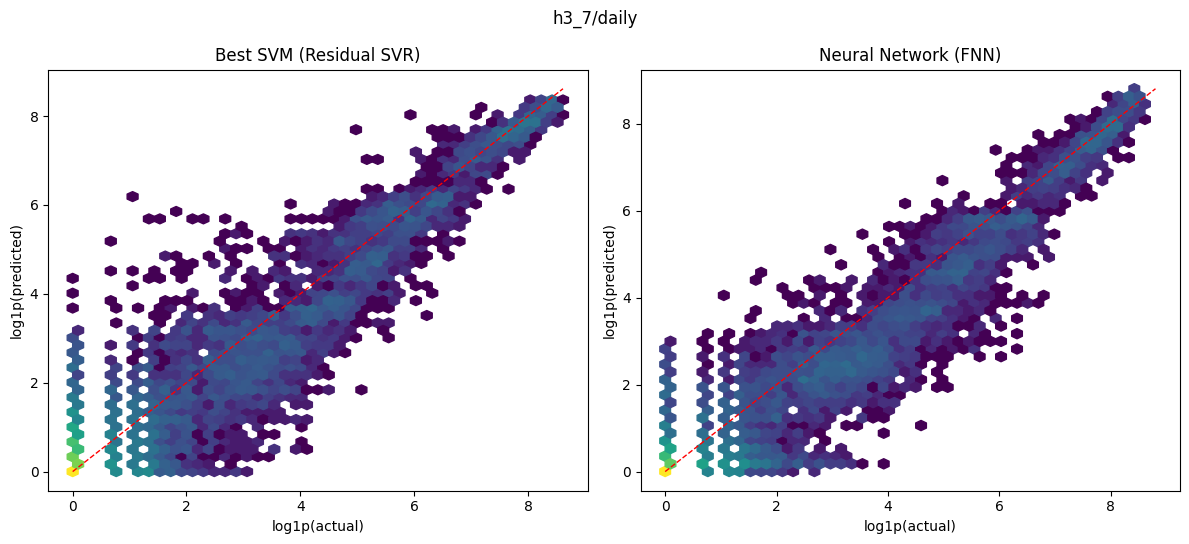

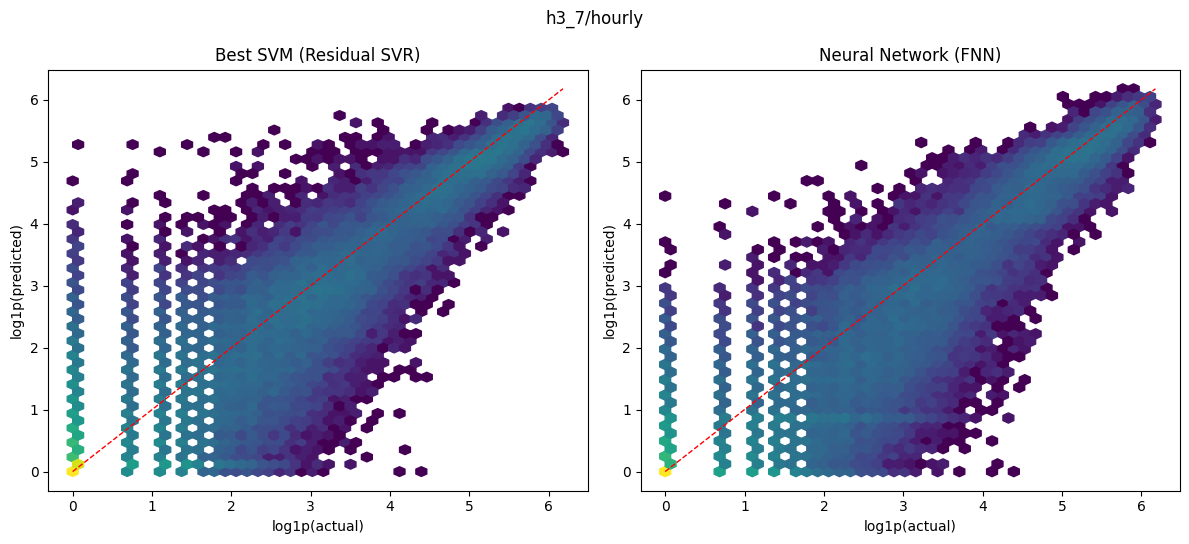

In [29]:
#| label: fig-svm-pred-vs-actual
#| fig-cap: "Predicted vs. actual demand (log1p scale) per temporal resolution."
for temporal, testing_df in comparisons.items():
    models = list(predictions.values())
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5.5), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    y_log = np.log1p(testing_df[TRUTH].values)
    for ax, p in zip(axes[0], models):
        pred_log = np.log1p(testing_df[p["col"]].values)
        ax.hexbin(y_log, pred_log, gridsize=45, cmap="viridis", mincnt=1, bins="log")
        lim = max(y_log.max(), pred_log.max())
        ax.plot([0, lim], [0, lim], color="red", linewidth=1, linestyle="--")
        ax.set_title(p["name"])
        ax.set_xlabel("log1p(actual)")
        ax.set_ylabel("log1p(predicted)")
    fig.tight_layout()
    plt.show()

## Spatial prediction quality

The aggregate metrics above collapse the whole city into a single number and hide strong
**spatial** variation in how well each model performs. Here we aggregate error by H3 hexagon and
compare whichever of the SVM / the neural network are available, side by side.

- **MAE per hexagon** -- the absolute size of the prediction miss (trips/day).
- **Relative error per hexagon** -- the miss size relative to that cell's own mean demand.
- **R² per hexagon** -- how much of each cell's day-to-day demand *variation* the model explains.
  Cells whose demand is essentially flat have no variation to explain, so their R² is undefined
  and they are greyed out.


In [30]:
# Community area outlines, used as a spatial reference overlay in the choropleths. The dedicated
# chicago_community_areas.gpkg file referenced by earlier versions of this notebook does not
# exist -- dissolve the census-tract file by commarea instead, the same fix 3.6b uses.
tracts = gpd.read_file(Path("..") / "data" / "chicago_census_comm.gpkg")
community_areas = tracts.dissolve(by="commarea")


def get_hexagon_grid(data, h3_col="h3_index"):
    """Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source."""
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        df = pd.DataFrame({"h3_index": list(data)})
        h3_list = df["h3_index"]
    else:
        df = data.reset_index(drop=True)
        h3_list = df[h3_col]
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def get_hexagon_performance_metrics(df_eval, pred_col, target_col=TARGET, h3_col="h3_index_7"):
    """Compute MAE/RMSE/R2/relative-error per hexagon for one prediction column."""
    d = df_eval.assign(
        abs_err=(df_eval[target_col] - df_eval[pred_col]).abs(),
        sq_err=(df_eval[target_col] - df_eval[pred_col]) ** 2,
    )
    grp = d.groupby(h3_col)
    hex_perf = grp.agg(
        n_obs=(target_col, "size"),
        mean_actual=(target_col, "mean"),
        var_actual=(target_col, "var"),
        mae=("abs_err", "mean"),
        mse=("sq_err", "mean"),
    )
    hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
    ss_res = grp["sq_err"].sum()
    ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
    hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
    hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
    hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
    hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col=h3_col)
    return hex_perf, hex_perf_gdf


def create_choropleth_plot(ax, gdf, value_col, title="", cmap="YlOrRd", k=7):
    """Plot one quantile choropleth of a hexagon-level metric onto ax, with a Chicago basemap and
    community-area boundary overlay."""
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap, scheme="quantiles", k=k,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)


In [31]:
# (hex_perf, hex_gdf) per model, keyed the same way as `predictions`. Computed on the test set.
hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col="h3_index_7")
           for key, p in predictions.items()}

### Map 1: mean absolute error (MAE) per hexagon

Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop;
the quiet outskirts have tiny MAE simply because there is little demand.


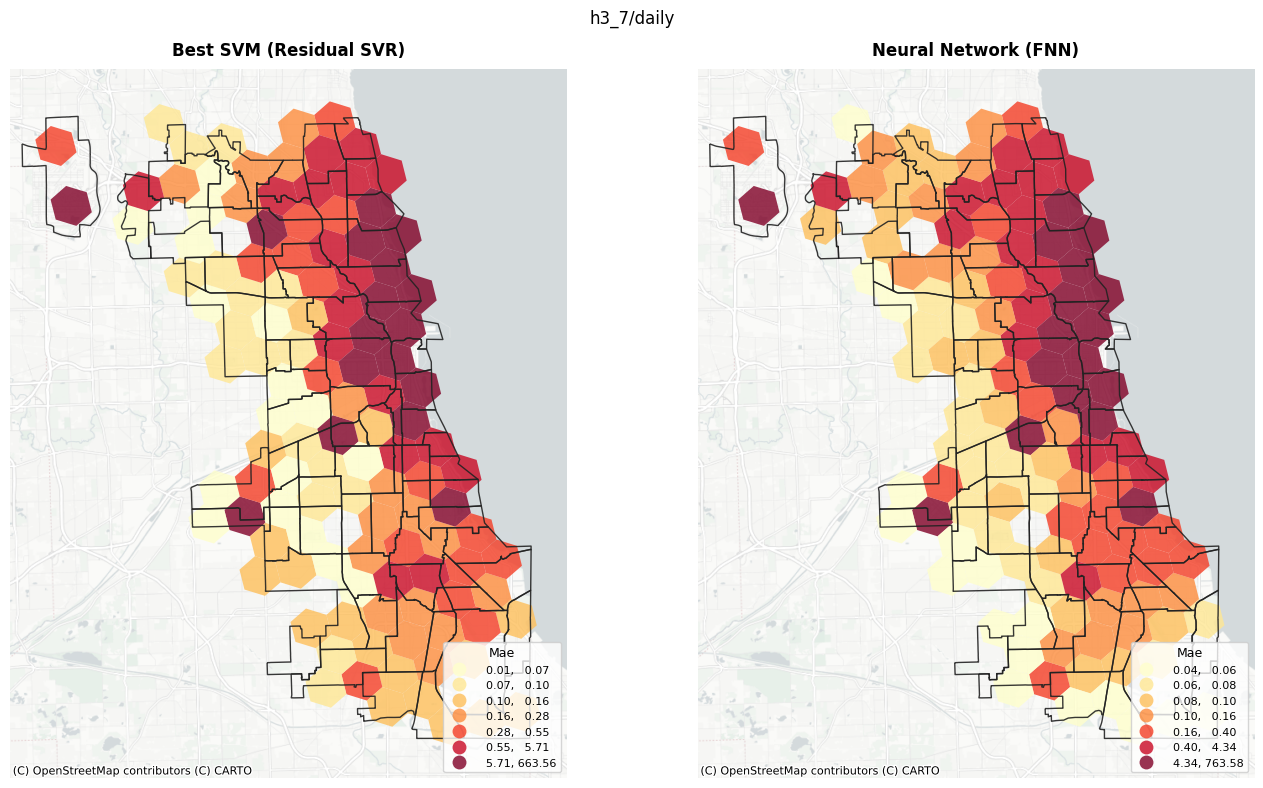

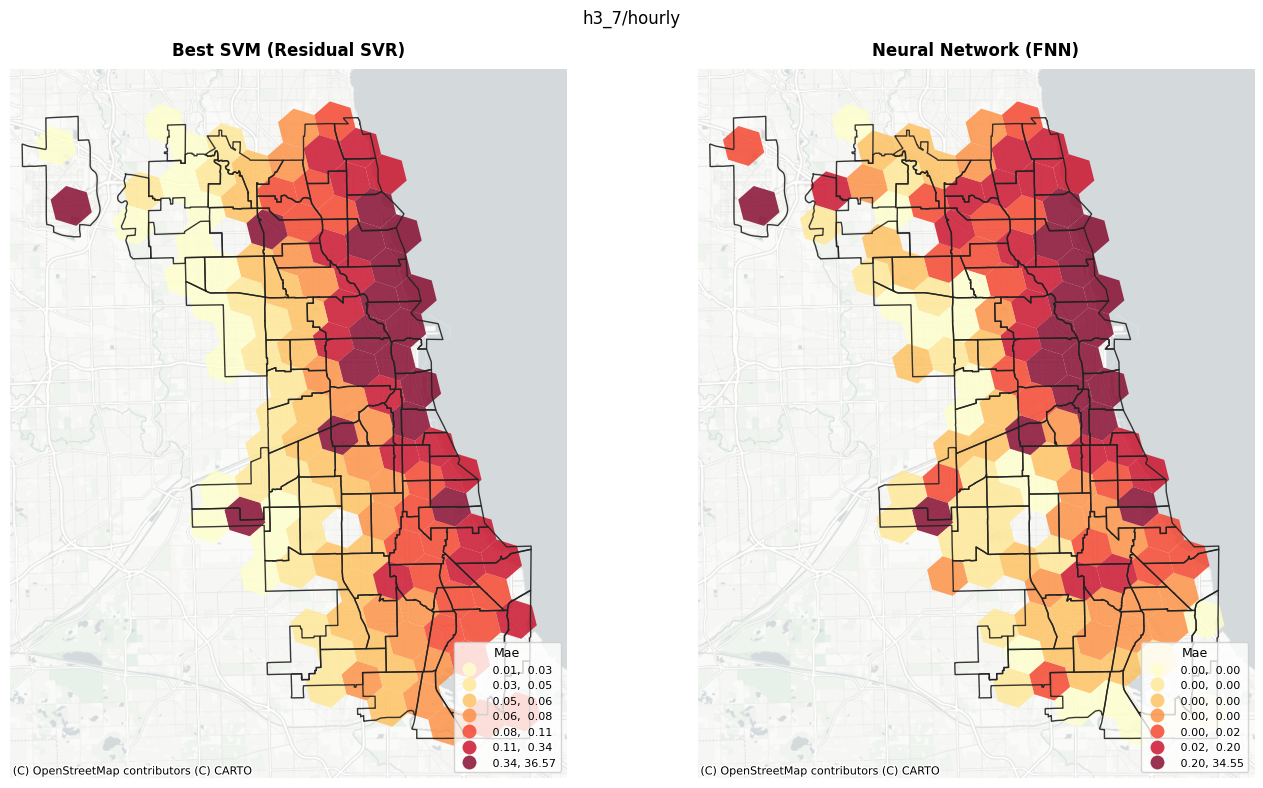

In [32]:
#| label: fig-svm-hex-mae
#| fig-cap: "MAE per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "mae", title=predictions[key]["name"])
    plt.tight_layout()
    plt.show()


### Map 2: mean relative error (MRE) per hexagon

The miss size relative to each cell's own mean demand -- this is what makes small-demand
outskirts visible instead of always looking "perfect" on raw MAE alone.


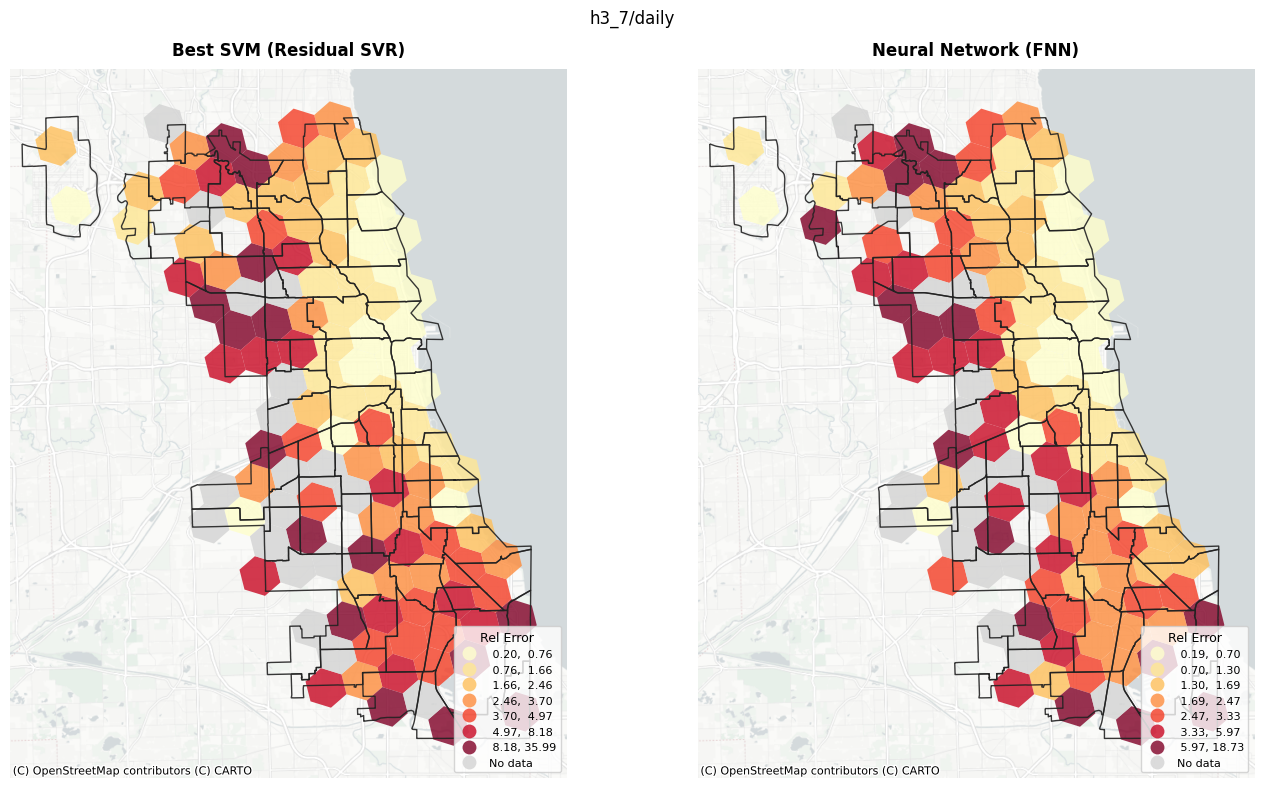

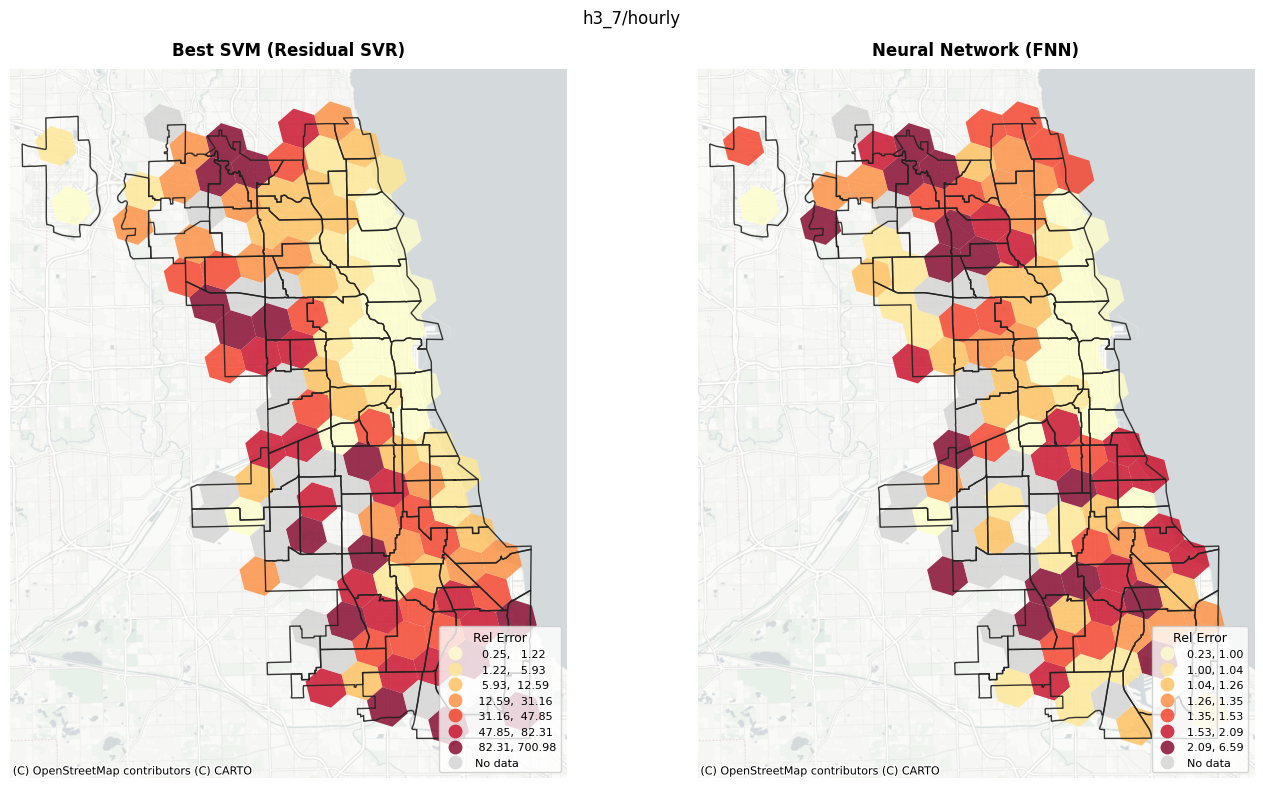

In [33]:
#| label: fig-svm-hex-mre
#| fig-cap: "Relative error per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "rel_error", title=predictions[key]["name"])
    plt.tight_layout()
    plt.show()


### Map 3: coefficient of determination (R2) per hexagon

Green = the day-to-day demand pattern is captured well; red = poorly; grey = too little demand
variation to assess.


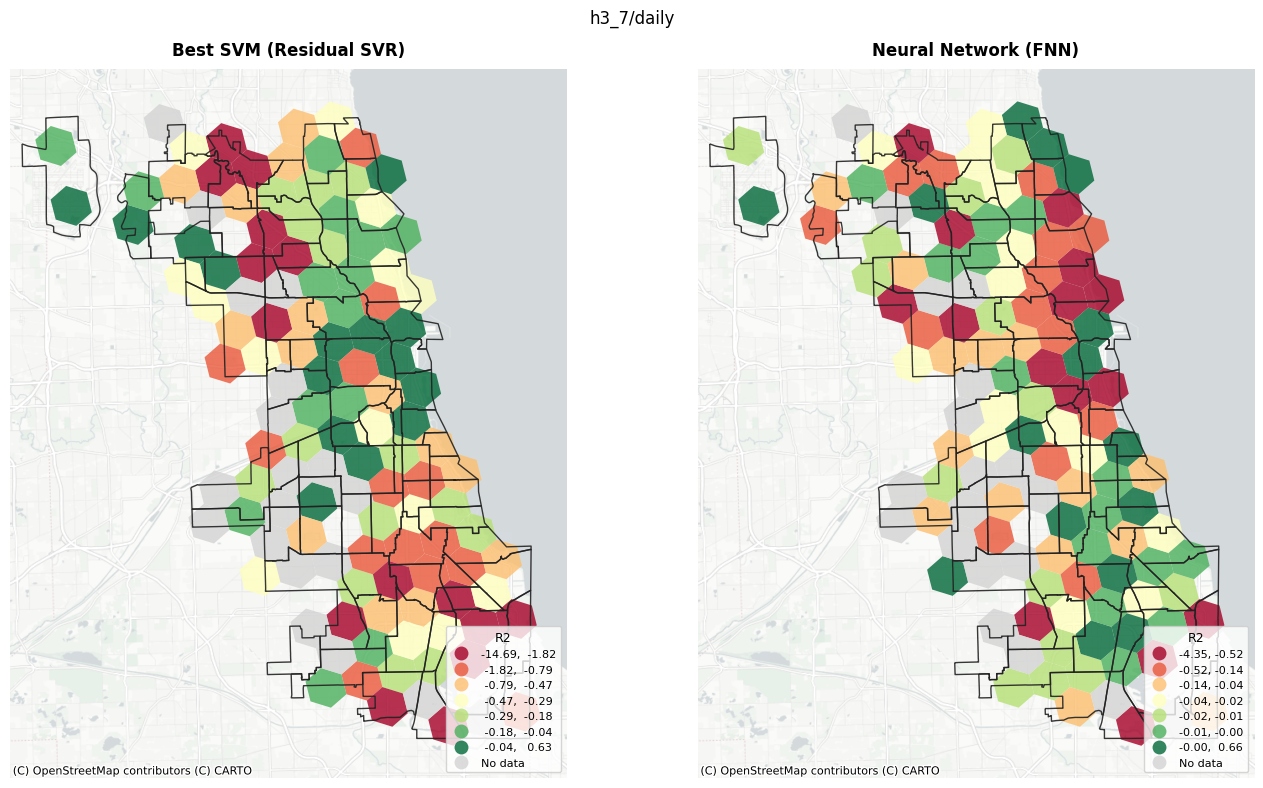

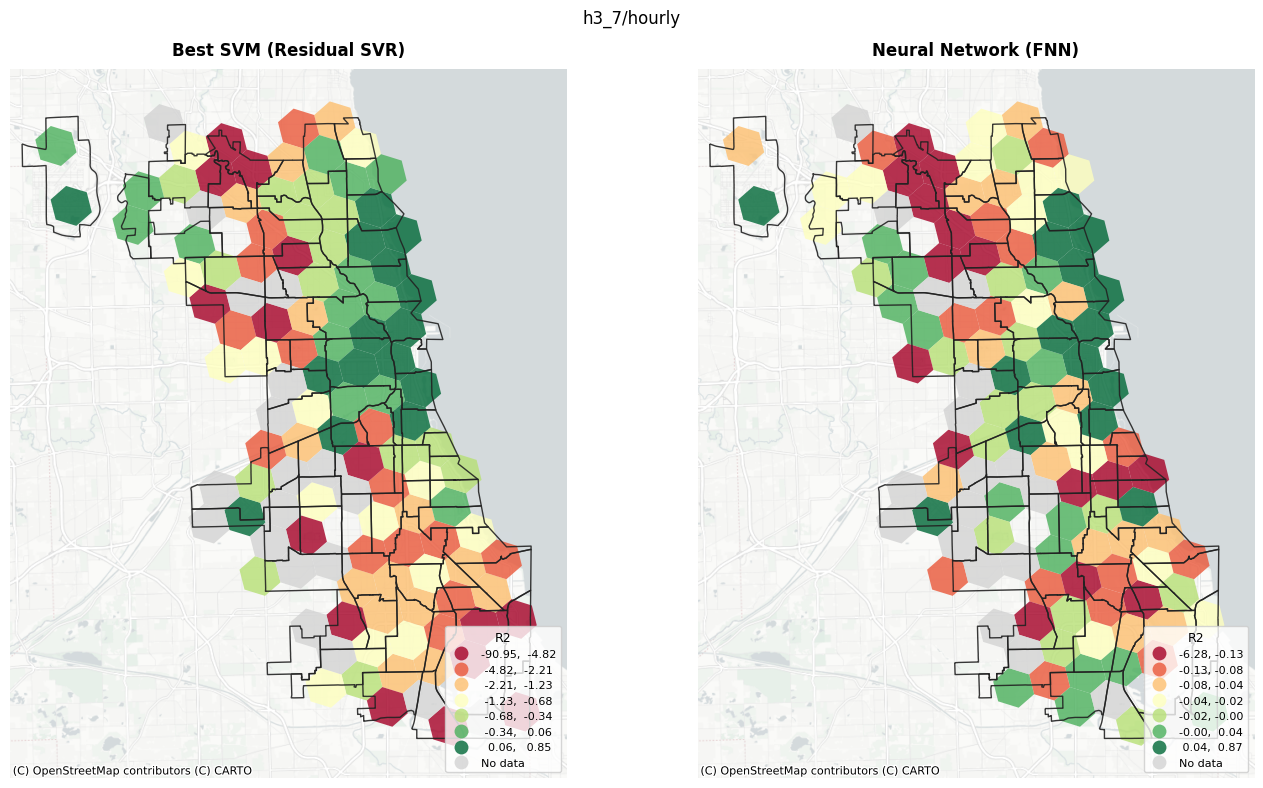

In [34]:
#| label: fig-svm-hex-r2
#| fig-cap: "R² per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "r2", title=predictions[key]["name"], cmap="RdYlGn")
    plt.tight_layout()
    plt.show()

### Map 4: where does one model beat the other?

The three maps above put the SVM and the NN side by side, but reading "who wins where" off two
separate color scales is hard. This map plots the difference directly:
`MAE_NN - MAE_SVM` per hexagon. Blue means the SVM has the lower error there (SVM wins); red
means the NN does.


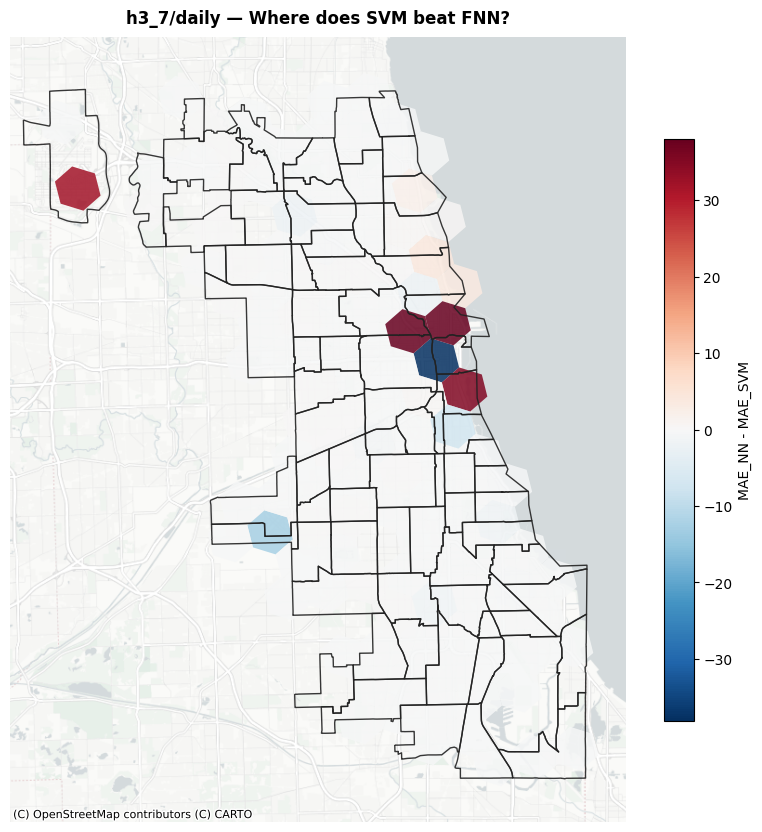

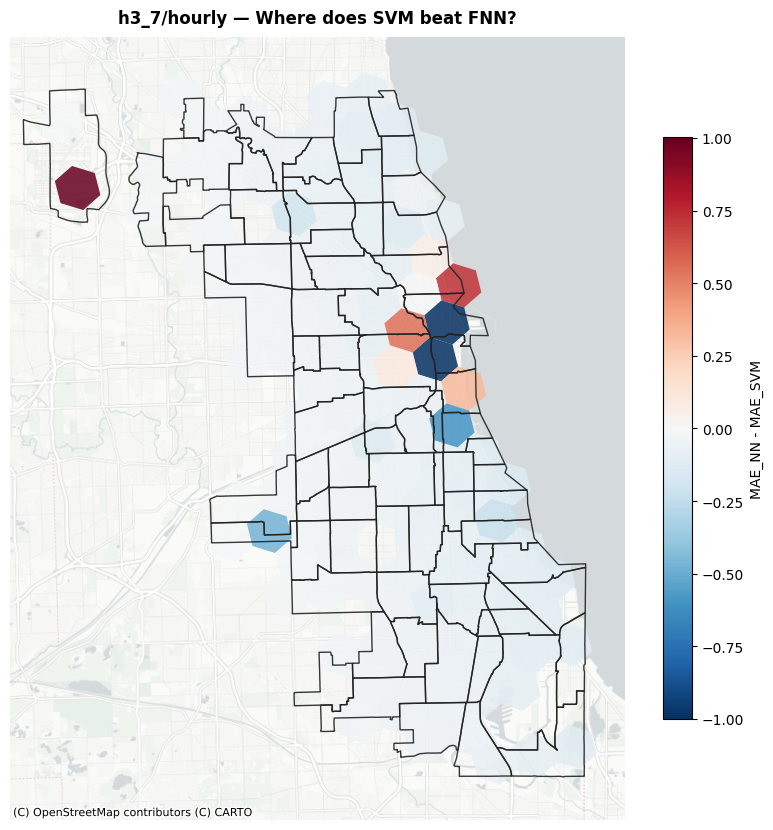

In [35]:
#| label: fig-svm-vs-nn-hex-delta
#| fig-cap: "MAE_NN - MAE_SVM per hexagon per temporal resolution. Blue = SVM wins, red = FNN wins."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    hex_perf_svm, _ = hex_data["svm"]
    hex_perf_nn, _ = hex_data["nn"]
    delta = hex_perf_svm[[INDEX, "mae"]].merge(hex_perf_nn[[INDEX, "mae"]], on=INDEX, suffixes=("_svm", "_nn"))
    delta["mae_delta"] = delta["mae_nn"] - delta["mae_svm"]
    delta_gdf = get_hexagon_grid(delta, h3_col=INDEX)
    bmax = delta_gdf["mae_delta"].abs().quantile(0.98)
    fig, ax = plt.subplots(figsize=(8, 10))
    delta_gdf.to_crs(epsg=3857).plot(
        ax=ax, column="mae_delta", cmap="RdBu_r", vmin=-bmax, vmax=bmax,
        edgecolor="none", alpha=0.85, legend=True, zorder=1,
        legend_kwds=dict(label="MAE_NN - MAE_SVM", shrink=0.6),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(f"h3_7/{temporal} — Where does SVM beat FNN?", fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


## Time Performance Analysis

`h3_7/daily` has no hour-of-day feature (each row is already a full day), so the temporal
breakdown here is by day of week only.


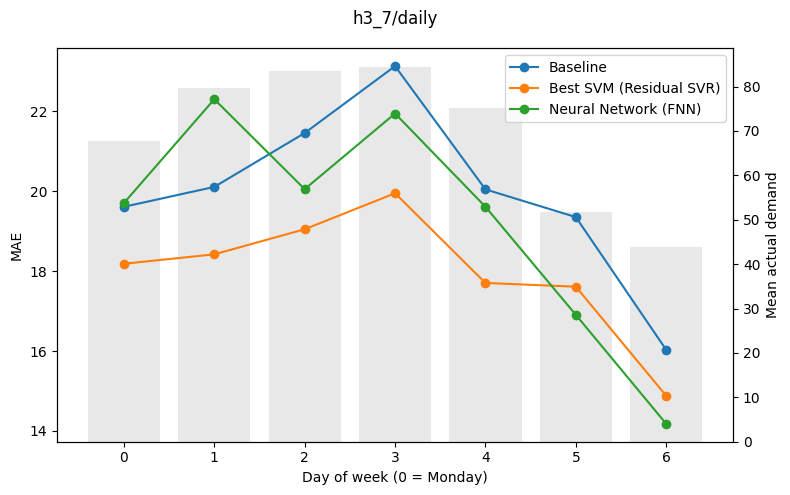

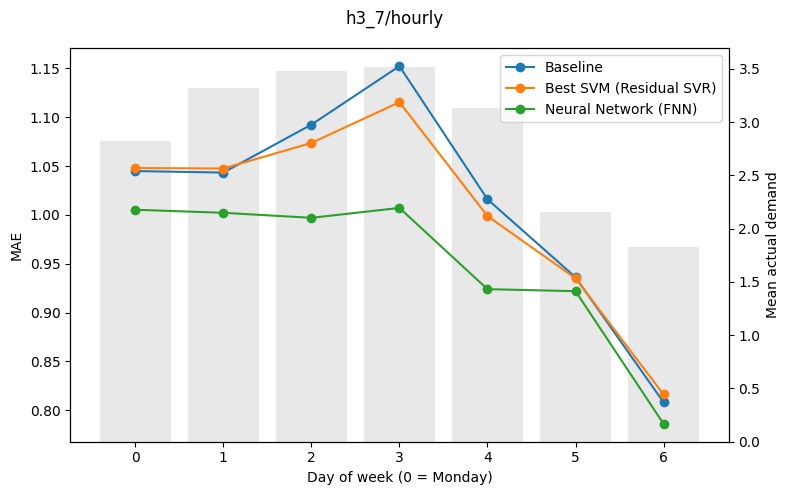

In [36]:
#| label: fig-svm-vs-nn-dayofweek
#| fig-cap: "Test MAE by day of week per temporal resolution."
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"h3_7/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("MAE")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

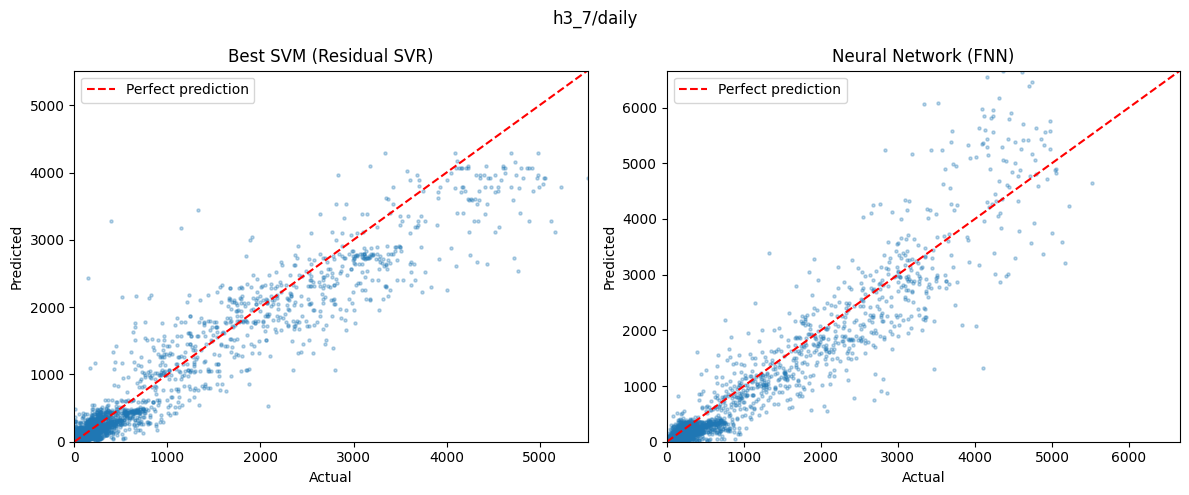

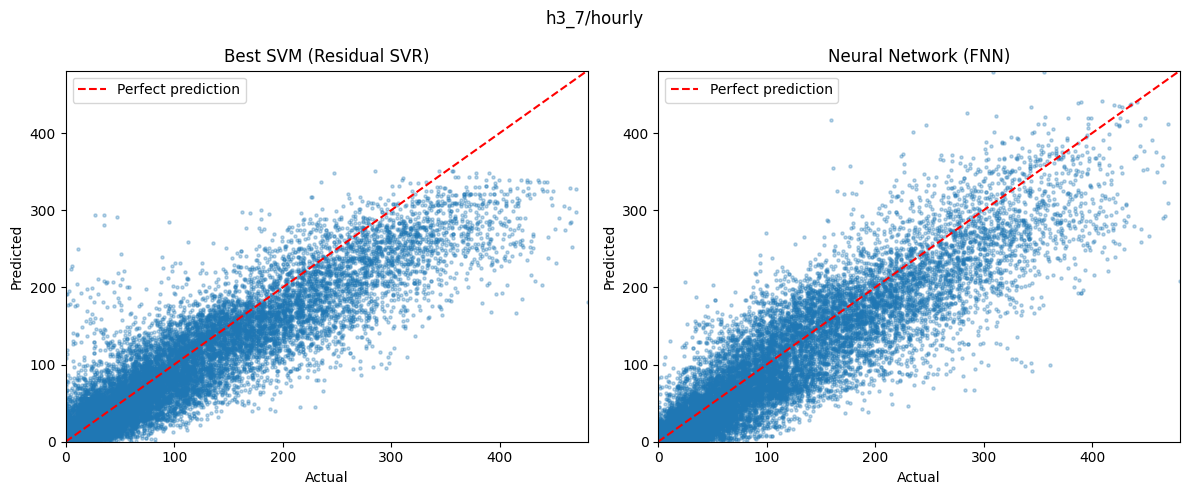

In [37]:
#| label: fig-svm-vs-nn-scatter
#| fig-cap: "Actual vs. predicted demand per temporal resolution."
for temporal, testing_df in comparisons.items():
    y_true = testing_df[TRUTH].values
    fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, p) in zip(axes[0], predictions.items()):
        pred = testing_df[p["col"]].values
        lim = max(y_true.max(), pred.max())
        ax.scatter(y_true, pred, alpha=0.3, s=5)
        ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(p["name"])
        ax.legend()
    plt.tight_layout()
    plt.show()

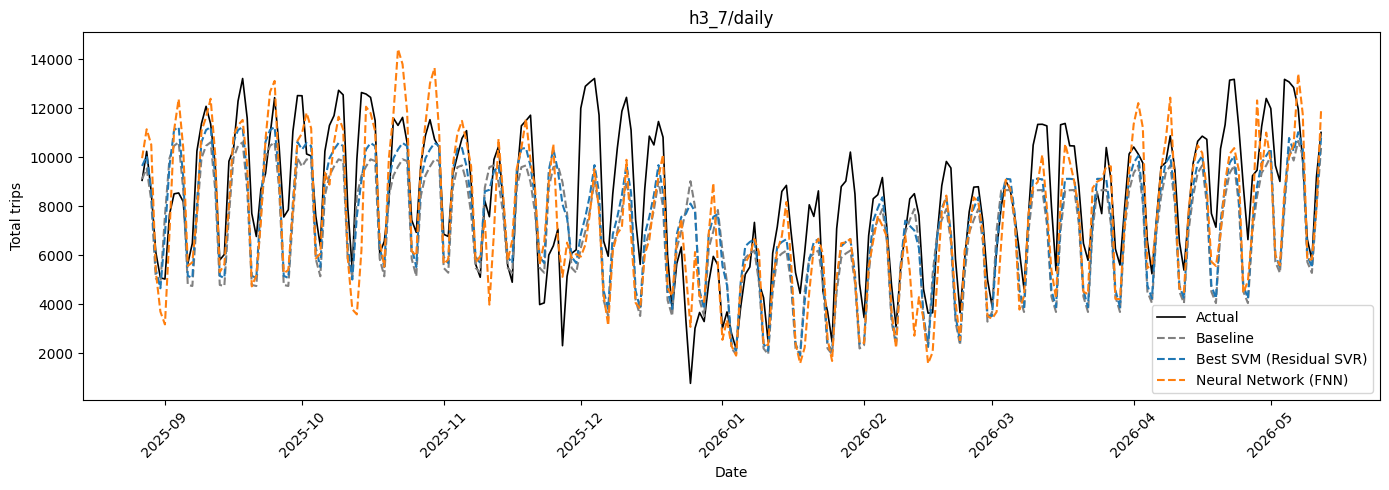

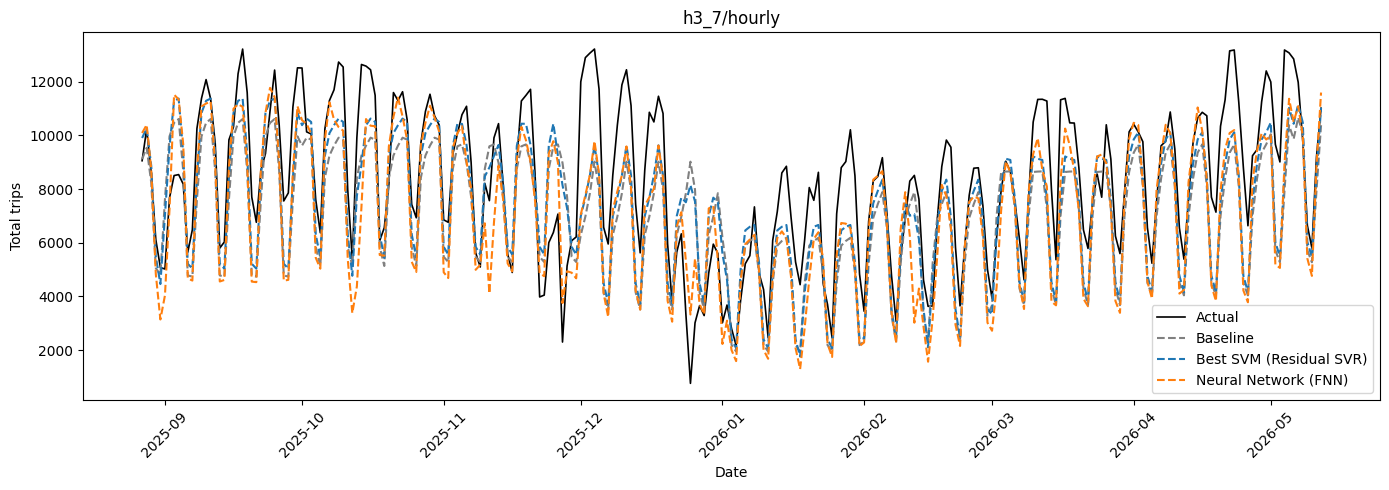

In [38]:
#| label: fig-svm-vs-nn-timeseries
#| fig-cap: "City-wide demand over the test period per temporal resolution."
for temporal, testing_df in comparisons.items():
    ts = testing_df.copy()
    ts["date"] = pd.to_datetime(ts["timestamp"]).dt.date
    daily_agg = ts.groupby("date").agg(
        actual=(TRUTH, "sum"),
        baseline=(BASELINE_COL, "sum"),
    ).reset_index()
    for p in predictions.values():
        daily_agg[p["name"]] = ts.groupby("date")[p["col"]].sum().values

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_title(f"h3_7/{temporal}")
    ax.plot(daily_agg["date"], daily_agg["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(daily_agg["date"], daily_agg["baseline"], label="Baseline", linestyle="--", color="gray")
    for p in predictions.values():
        ax.plot(daily_agg["date"], daily_agg[p["name"]], label=p["name"], linestyle="--")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total trips")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## When does each model do best?

The maps above show *where* errors fall; this table shows *when*. It breaks test MAE down by
demand magnitude (zero / low / medium / high) and by weather (dry vs. rainy days), so a model that
wins overall but loses on, say, the busiest cells or on rainy days is not hidden behind a single
average. The same segmentation `3.6b` uses for the direct-vs-residual comparison.

In [39]:
#| label: tbl-svm-vs-nn-segments
#| fig-cap: "Test MAE by demand band and weather per temporal resolution."
def segment_masks(df, y):
    df["is_rainy"] = (df["total_precip_mm"] >= 0.1).astype(int)
    return {
        "all": np.ones(len(df), dtype=bool),
        "zero demand (y = 0)": y == 0,
        "low demand (1-10)": (y >= 1) & (y <= 10),
        "medium demand (11-100)": (y > 10) & (y <= 100),
        "high demand (> 100)": y > 100,
        "dry days": df["is_rainy"].values == 0,
        "rainy days": df["is_rainy"].values == 1,
    }

for temporal, testing_df in comparisons.items():
    print(f"\n--- h3_7/{temporal} ---")
    y_true = testing_df[TRUTH].values
    rows = []
    for seg_name, mask in segment_masks(testing_df, y_true).items():
        if mask.sum() == 0:
            continue
        rows.append({"segment": seg_name, "Model": "Baseline", "n": int(mask.sum()),
                     "MAE": mean_absolute_error(y_true[mask], testing_df[BASELINE_COL].values[mask])})
        for p in predictions.values():
            rows.append({"segment": seg_name, "Model": p["name"], "n": int(mask.sum()),
                         "MAE": mean_absolute_error(y_true[mask], testing_df[p["col"]].values[mask])})
    display(pd.DataFrame(rows).set_index(["segment", "Model"]).round(3))


--- h3_7/daily ---


n      MAE
segment                Model                                  
all                    Baseline                 30821   19.962
                       Best SVM (Residual SVR)  30821   17.971
                       Neural Network (FNN)     30821   19.243
zero demand (y = 0)    Baseline                 24617    0.220
                       Best SVM (Residual SVR)  24617    0.284
                       Neural Network (FNN)     24617    0.150
low demand (1-10)      Baseline                  2629    4.600
                       Best SVM (Residual SVR)   2629    4.474
                       Neural Network (FNN)      2629    2.801
medium demand (11-100) Baseline                  1717   25.645
                       Best SVM (Residual SVR)   1717   26.287
                       Neural Network (FNN)      1717   23.290
high demand (> 100)    Baseline                  1858  298.013
                       Best SVM (Residual SVR)   1858  263.732
                       Neural Network (FNN)      1858  291.732
dry days               Baseline                 27251   20.019
                       Best SVM (Residual SVR)  27251   17.944
                       Neural Network (FNN)     27251   18.813
rainy days             Baseline                  3570   19.530
                       Best SVM (Residual SVR)   3570   18.180
                       Neural Network (FNN)      3570   22.522


--- h3_7/hourly ---


n     MAE
segment                Model                                  
all                    Baseline                 739704   1.013
                       Best SVM (Residual SVR)  739704   1.005
                       Neural Network (FNN)     739704   0.949
zero demand (y = 0)    Baseline                 688031   0.050
                       Best SVM (Residual SVR)  688031   0.112
                       Neural Network (FNN)     688031   0.027
low demand (1-10)      Baseline                  26481   3.408
                       Best SVM (Residual SVR)   26481   3.383
                       Neural Network (FNN)      26481   3.077
medium demand (11-100) Baseline                  17991  15.147
                       Best SVM (Residual SVR)   17991  14.281
                       Neural Network (FNN)      17991  15.574
high demand (> 100)    Baseline                   7201  48.961
                       Best SVM (Residual SVR)    7201  44.400
                       Neural Network (FNN)       7201  44.729
dry days               Baseline                 650692   1.004
                       Best SVM (Residual SVR)  650692   0.996
                       Neural Network (FNN)     650692   0.940
rainy days             Baseline                  89012   1.078
                       Best SVM (Residual SVR)   89012   1.074
                       Neural Network (FNN)      89012   1.017

## Verdict

<!-- TODO fill in now that both the SVM and NN test predictions are loaded and every cell runs on
the held-out test set. Points to check:
- Overall: does the NN beat the best SVM on the test set (tbl-svm-vs-nn-overall)?
- By segment: where does each model do best/worst across demand bands and dry/rainy days
  (tbl-svm-vs-nn-segments)?
- Spatially: where does fig-svm-vs-nn-hex-delta show the NN winning vs. the SVM winning -- is it
  concentrated downtown, in the sparse outskirts, or spread evenly?
- Temporally: does either model handle weekends vs. weekdays differently (fig-svm-vs-nn-dayofweek)?
- Update sections/04-demand-prediction.qmd's Model Comparison section with the outcome. -->
